In [1]:
import numpy as np
import os 
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.linear_model import LogisticRegression 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.pipeline import make_pipeline

from sklearn.model_selection import cross_val_score,train_test_split
from imblearn.under_sampling import RandomUnderSampler 



from sklearn.svm import SVC, LinearSVC 
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV

from sklearn.decomposition import PCA
from mlxtend.plotting import plot_decision_regions
from sklearn.datasets import make_classification



%matplotlib inline


In [2]:
from sklearn import linear_model, preprocessing
#Load the dataset
df = pd.read_csv("~/Desktop/kddcup99_csv.csv", on_bad_lines="skip")
df.drop_duplicates(inplace=True)
#df= df.sample(frac=0.1)
df.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,http,SF,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal
1,0,tcp,http,SF,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal
2,0,tcp,http,SF,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal
3,0,tcp,http,SF,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal
4,0,tcp,http,SF,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal


In [3]:
print(df.iloc[:, -1].value_counts())

label
normal             87831
neptune            51820
back                 968
teardrop             918
satan                906
warezclient          893
ipsweep              651
smurf                641
portsweep            416
pod                  206
nmap                 158
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  19
imap                  12
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


## Dos vs Non-Dos 
### Distinguising one-vs-many 

In [4]:
dos_types = ['back', 'land', 'neptune', 'pod', 'smurf', 'teardrop']
def classify_dos(row):
    return "Dos" if row in dos_types else "non-Dos"
df['class'] = df['label'].apply(classify_dos)
df.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,class
0,0,tcp,http,SF,181,5450,0,0,0,0,...,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal,non-Dos
1,0,tcp,http,SF,239,486,0,0,0,0,...,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal,non-Dos
2,0,tcp,http,SF,235,1337,0,0,0,0,...,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal,non-Dos
3,0,tcp,http,SF,219,1337,0,0,0,0,...,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal,non-Dos
4,0,tcp,http,SF,217,2032,0,0,0,0,...,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal,non-Dos


In [5]:
df.dtypes

duration                         int64
protocol_type                   object
service                         object
flag                            object
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
lnum_compromised                 int64
lroot_shell                      int64
lsu_attempted                    int64
lnum_root                        int64
lnum_file_creations              int64
lnum_shells                      int64
lnum_access_files                int64
lnum_outbound_cmds               int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_rate          

In [6]:


df = pd.get_dummies(df, columns=['protocol_type', 'flag', 'class'], drop_first=True)
label_enc = LabelEncoder()
df['service'] = label_enc.fit_transform(df['service'])
df['label'] = label_enc.fit_transform(df['label'])

df.head()

,duration,service,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,...,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH,class_non-Dos
0,0,22,181,5450,0,0,0,0,0,1,...,False,False,False,False,False,False,False,True,False,True
1,0,22,239,486,0,0,0,0,0,1,...,False,False,False,False,False,False,False,True,False,True
2,0,22,235,1337,0,0,0,0,0,1,...,False,False,False,False,False,False,False,True,False,True
3,0,22,219,1337,0,0,0,0,0,1,...,False,False,False,False,False,False,False,True,False,True
4,0,22,217,2032,0,0,0,0,0,1,...,False,False,False,False,False,False,False,True,False,True


In [20]:
X = df.drop(columns=['class_non-Dos'])
y = df['class_non-Dos']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


rus = RandomUnderSampler(sampling_strategy='auto', random_state=42)
X_train, y_train = rus.fit_resample(X_train, y_train)

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test) 

In [9]:
svm_model = SVC(kernel='sigmoid', C=0.01,random_state=42)
svm_model.fit(X_train_scaled, y_train)

score = svm_model.score(X_test_scaled, y_test)
print(f"Model accuracy: {score}")


y_pred = svm_model.predict(X_test_scaled)


print("Classification Report:")
print(classification_report(y_test, y_pred))


Model accuracy: 0.9356389737953773
Classification Report:
              precision    recall  f1-score   support

       False       0.88      0.96      0.92     10929
        True       0.97      0.92      0.95     18188

    accuracy                           0.94     29117
   macro avg       0.93      0.94      0.93     29117
weighted avg       0.94      0.94      0.94     29117



In [10]:
svm_model = SVC(kernel='rbf', C=0.01,random_state=42)
svm_model.fit(X_train_scaled, y_train)

score = svm_model.score(X_test_scaled, y_test)
print(f"Model accuracy: {score}")


y_pred = svm_model.predict(X_test_scaled)


print("Classification Report:")
print(classification_report(y_test, y_pred))


Model accuracy: 0.9905210014768004
Classification Report:
              precision    recall  f1-score   support

       False       1.00      0.98      0.99     10929
        True       0.99      1.00      0.99     18188

    accuracy                           0.99     29117
   macro avg       0.99      0.99      0.99     29117
weighted avg       0.99      0.99      0.99     29117



In [11]:
svm_model = SVC(kernel='poly', C=0.01,random_state=42)
svm_model.fit(X_train_scaled, y_train)

score = svm_model.score(X_test_scaled, y_test)
print(f"Model accuracy: {score}")


y_pred = svm_model.predict(X_test_scaled)


print("Classification Report:")
print(classification_report(y_test, y_pred))


Model accuracy: 0.9910018202424701
Classification Report:
              precision    recall  f1-score   support

       False       1.00      0.98      0.99     10929
        True       0.99      1.00      0.99     18188

    accuracy                           0.99     29117
   macro avg       0.99      0.99      0.99     29117
weighted avg       0.99      0.99      0.99     29117



In [24]:
svm_model = LinearSVC(C=0.01,random_state=42)
svm_model.fit(X_train_scaled, y_train)

score = svm_model.score(X_test_scaled, y_test)
print(f"Model accuracy: {score}")


y_pred = svm_model.predict(X_test_scaled)


print("Classification Report:")
print(classification_report(y_test, y_pred))


Model accuracy: 0.9959473846893567
Classification Report:
              precision    recall  f1-score   support

       False       1.00      0.99      0.99     10929
        True       1.00      1.00      1.00     18188

    accuracy                           1.00     29117
   macro avg       1.00      1.00      1.00     29117
weighted avg       1.00      1.00      1.00     29117



# 1. Compare the results for each of the kernels.
## Sigmoid Kernel

* Model accuracy: 0.9356

  * Pros & Cons:

    * Cons: The sigmoid kernel tends to underperform compared with the other kernels tested. Its lower accuracy suggests it fails to capture the underlying structure of the data effectively.

    * Additional context: The sigmoid kernel behaves similarly to a neural network activation function, but it is generally not as effective for most classification tasks unless the data fits very specific patterns.

    * Overall: Least effective kernel in this comparison.


## RBF (Radial Basis Function) Kernel

* Model accuracy: 0.9905

 * Pros & Cons:

    * Pros: The RBF kernel performs extremely well, achieving high accuracy. It is well-known for capturing complex nonlinear decision boundaries.

    * Cons: Because of its flexibility, it has an increased risk of overfitting, especially when hyperparameters (such as C and gamma) are not carefully tuned.

    * Additional context: RBF is one of the most widely used kernels due to its ability to model nonlinear patterns, but it can be computationally expensive on large datasets.


## Polynomial Kernel

* Model accuracy: 0.9910

  * Pros & Cons:

  * Pros: Achieves very high accuracy, only slightly below the linear kernel in this case. It can model interactions of different degrees, making it a strong option when relationships between features are not strictly linear.

  * Cons: The computational cost increases with the polynomial degree. Performance can degrade if the degree is poorly chosen or too high.

  * Additional context: Polynomial kernels can capture moderately complex patterns but may require careful tuning to avoid excessive complexity.

## Linear Kernel

  * Model accuracy: 0.9959

  *Pros & Cons:

  * Pros: Achieved the highest accuracy, suggesting the relationships in the dataset are largely linearly separable. It is computationally efficient, scalable, and less prone to overfitting compared to nonlinear kernels.

  * Additional advantages: Coefficients are interpretable, making it easier to extract feature importance and understand how the model makes decisions.

  *Cons: Less effective if the underlying patterns are highly nonlinear—though in this case, its performance shows that a linear boundary works best.


In [23]:
# Get feature weights
feature_importance = abs(svm_model.coef_[0])  # Absolute values of weights
feature_names = X.columns

# Sort features by importance
sorted_indices = np.argsort(feature_importance)[::-1]
top_features = [(feature_names[i], feature_importance[i]) for i in sorted_indices[:10]]

print("Top 10 Most Informative Features:")
for feature, weight in top_features:
    print(f"{feature}: {weight:.4f}")

Top 10 Most Informative Features:
wrong_fragment: 2.7940
label: 2.2711
diff_srv_rate: 1.2362
srv_count: 1.1254
same_srv_rate: 0.9327
dst_host_srv_diff_host_rate: 0.8763
protocol_type_udp: 0.8762
count: 0.7248
protocol_type_tcp: 0.6513
flag_S0: 0.6222


In [25]:
X2 = df.iloc[:, :2].reset_index(drop=True)
y  = y.reset_index(drop=True)

# Random 10%
idx = X2.sample(frac=0.10, random_state=42).index

# Subset
X_small = X2.loc[idx]
y_small = y.loc[idx]

# Scale
X_small_scaled = scaler.fit_transform(X_small)

print(X_small_scaled.shape)

(14558, 2)


In [26]:
svm_model = LinearSVC(C=0.01,random_state=42)
svm_model.fit(X_small_scaled, y_small)

score = svm_model.score(X_small_scaled, y_small)
print(f"Model accuracy: {score}")


y_pred = svm_model.predict(X_small_scaled)


print("Classification Report:")
print(classification_report(y_small, y_pred))

Model accuracy: 0.8501167742821816
Classification Report:
              precision    recall  f1-score   support

       False       0.75      0.90      0.82      5470
        True       0.93      0.82      0.87      9088

    accuracy                           0.85     14558
   macro avg       0.84      0.86      0.85     14558
weighted avg       0.86      0.85      0.85     14558



In [27]:
svm_model = SVC(kernel='rbf', C=0.01,random_state=42)
svm_model.fit(X_small_scaled, y_small)

score = svm_model.score(X_small_scaled, y_small)
print(f"Model accuracy: {score}")


y_pred = svm_model.predict(X_small_scaled)


print("Classification Report:")
print(classification_report(y_small, y_pred))

Model accuracy: 0.8500480835279571
Classification Report:
              precision    recall  f1-score   support

       False       0.75      0.91      0.82      5470
        True       0.94      0.82      0.87      9088

    accuracy                           0.85     14558
   macro avg       0.84      0.86      0.85     14558
weighted avg       0.87      0.85      0.85     14558



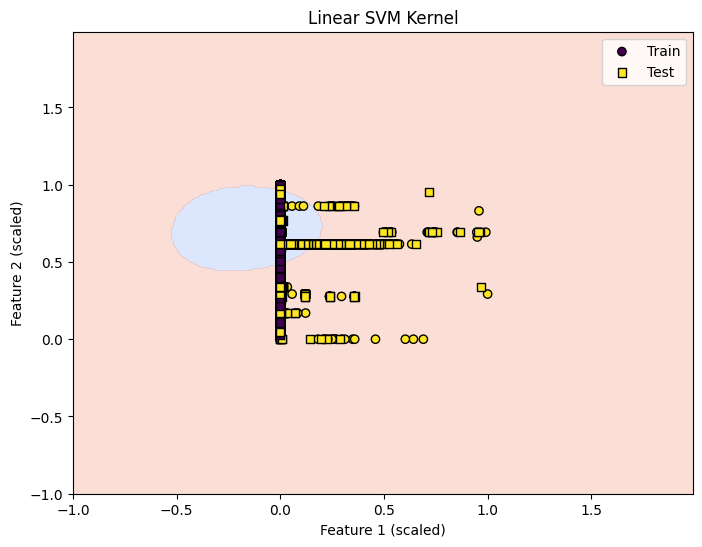

In [28]:
# Combine train and test for plotting
X_plot = np.vstack((X_train_scaled, X_test_scaled))
y_plot = np.hstack((y_train, y_test))

# Create meshgrid
x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
np.arange(y_min, y_max, 0.01))

# Predict on meshgrid
Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# Plot training points
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, 
            edgecolor='k', marker='o', label='Train')

# Plot testing points
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test, 
            edgecolor='k', marker='s', label='Test')

plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')
plt.title('Linear SVM Kernel')
plt.legend()
plt.show()